<a href="https://colab.research.google.com/github/rparson4/MarsTharsisGlaciers/blob/main/MarsObliquity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# prompt: load MontesSimulationCompile.csv into pandas dataframe and loop through rows checking if column2 values are N, if so, plot them as green circles

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load the CSV file into a pandas DataFrame.
try:
    # df = pd.read_csv('MontesSimulationCompile.csv')
    df00 = pd.read_csv('301003BIN_A_P000_N.ASC', delim_whitespace=True, header=None)
except FileNotFoundError:
    print("Error: '301003BIN_A_P000_N.ASC' not found. Please upload the file.")
    df00 = pd.DataFrame()  # Create an empty DataFrame to avoid further errors

/tmp/ipykernel_16147/182133514.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df00 = pd.read_csv('301003BIN_A_P000_N.ASC', delim_whitespace=True, header=None)


In [ ]:
# Load the CSV file into a pandas DataFrame.
try:
    # df = pd.read_csv('MontesSimulationCompile.csv')
    df22 = pd.read_csv('301003BIN_A_P022_N.ASC', delim_whitespace=True, header=None)
except FileNotFoundError:
    print("Error: '301003BIN_A_P022_N.ASC' not found. Please upload the file.")
    df22 = pd.DataFrame()  # Create an empty DataFrame to avoid further errors

/tmp/ipykernel_16147/649826492.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df22 = pd.read_csv('301003BIN_A_P022_N.ASC', delim_whitespace=True, header=None)


In [ ]:
df00.columns = ['Time (kyrs)', 'Eccentricity', 'Obliquity (r)', 'Precession']
df22.columns = ['Time (kyrs)', 'Eccentricity', 'Obliquity (r)', 'Precession']
df00.head()

,Time (kyrs),Eccentricity,Obliquity (r),Precession
0,0.0,0.093315,0.439638,1.239968
1,-1.0,0.092414,0.437554,1.126635
2,-2.0,0.091571,0.435541,1.013114
3,-3.0,0.090497,0.433597,0.896472
4,-4.0,0.089582,0.431733,0.782300


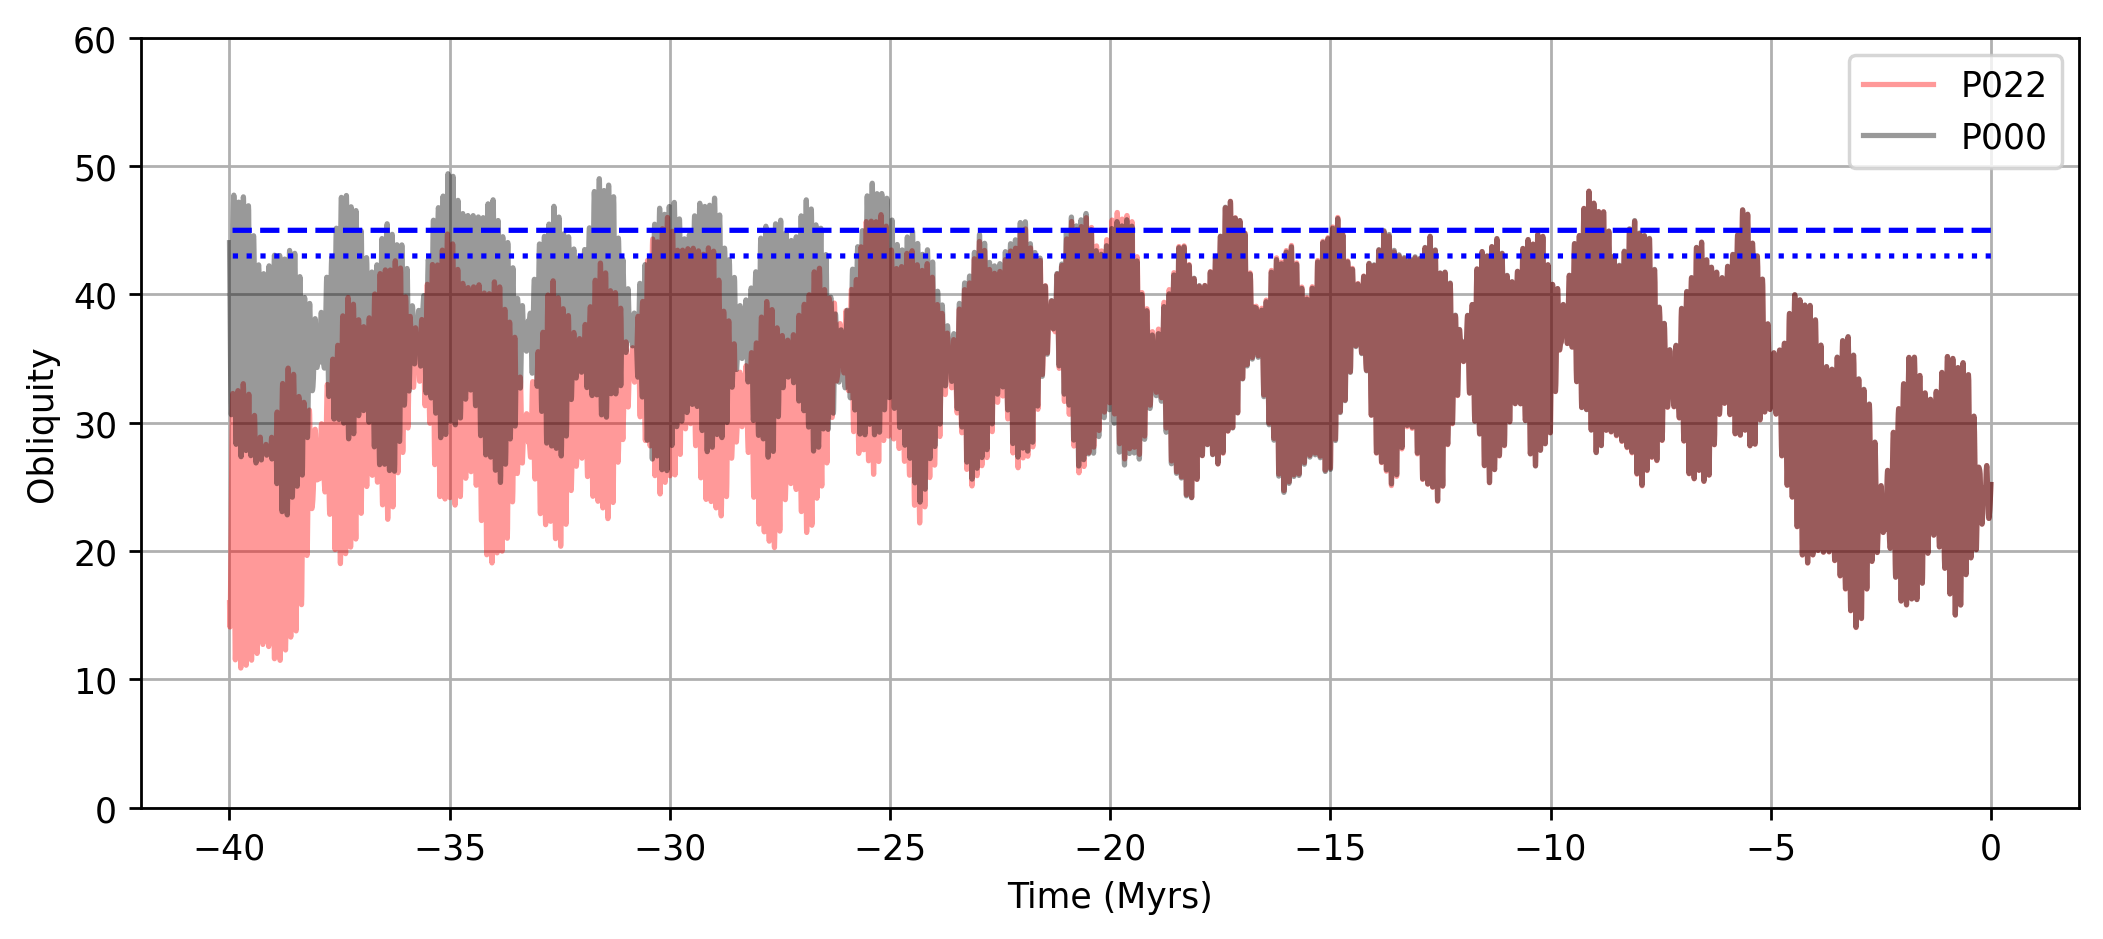

In [ ]:
plt.figure(figsize=(10, 4),dpi=250)
# plt.subplot(211)
plt.plot(df22.iloc[:40000, 0]/1000, df22.iloc[:40000, 2]*180./np.pi, 'red',label='P022',alpha=0.4)
plt.plot(df00.iloc[:40000, 0]/1000, df00.iloc[:40000, 2]*180./np.pi, 'black',label='P000',alpha=0.4)
plt.plot(df00.iloc[:40000, 0]/1000, np.ones(40000)*45, color="blue",linestyle='--',)
plt.plot(df00.iloc[:40000, 0]/1000, np.ones(40000)*43, color="blue",linestyle=':',)
plt.xlabel('Time (Myrs)')
plt.ylabel('Obliquity')
plt.ylim(0, 60)
# plt.title('Scatter plot of Column 1 vs Column 2')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

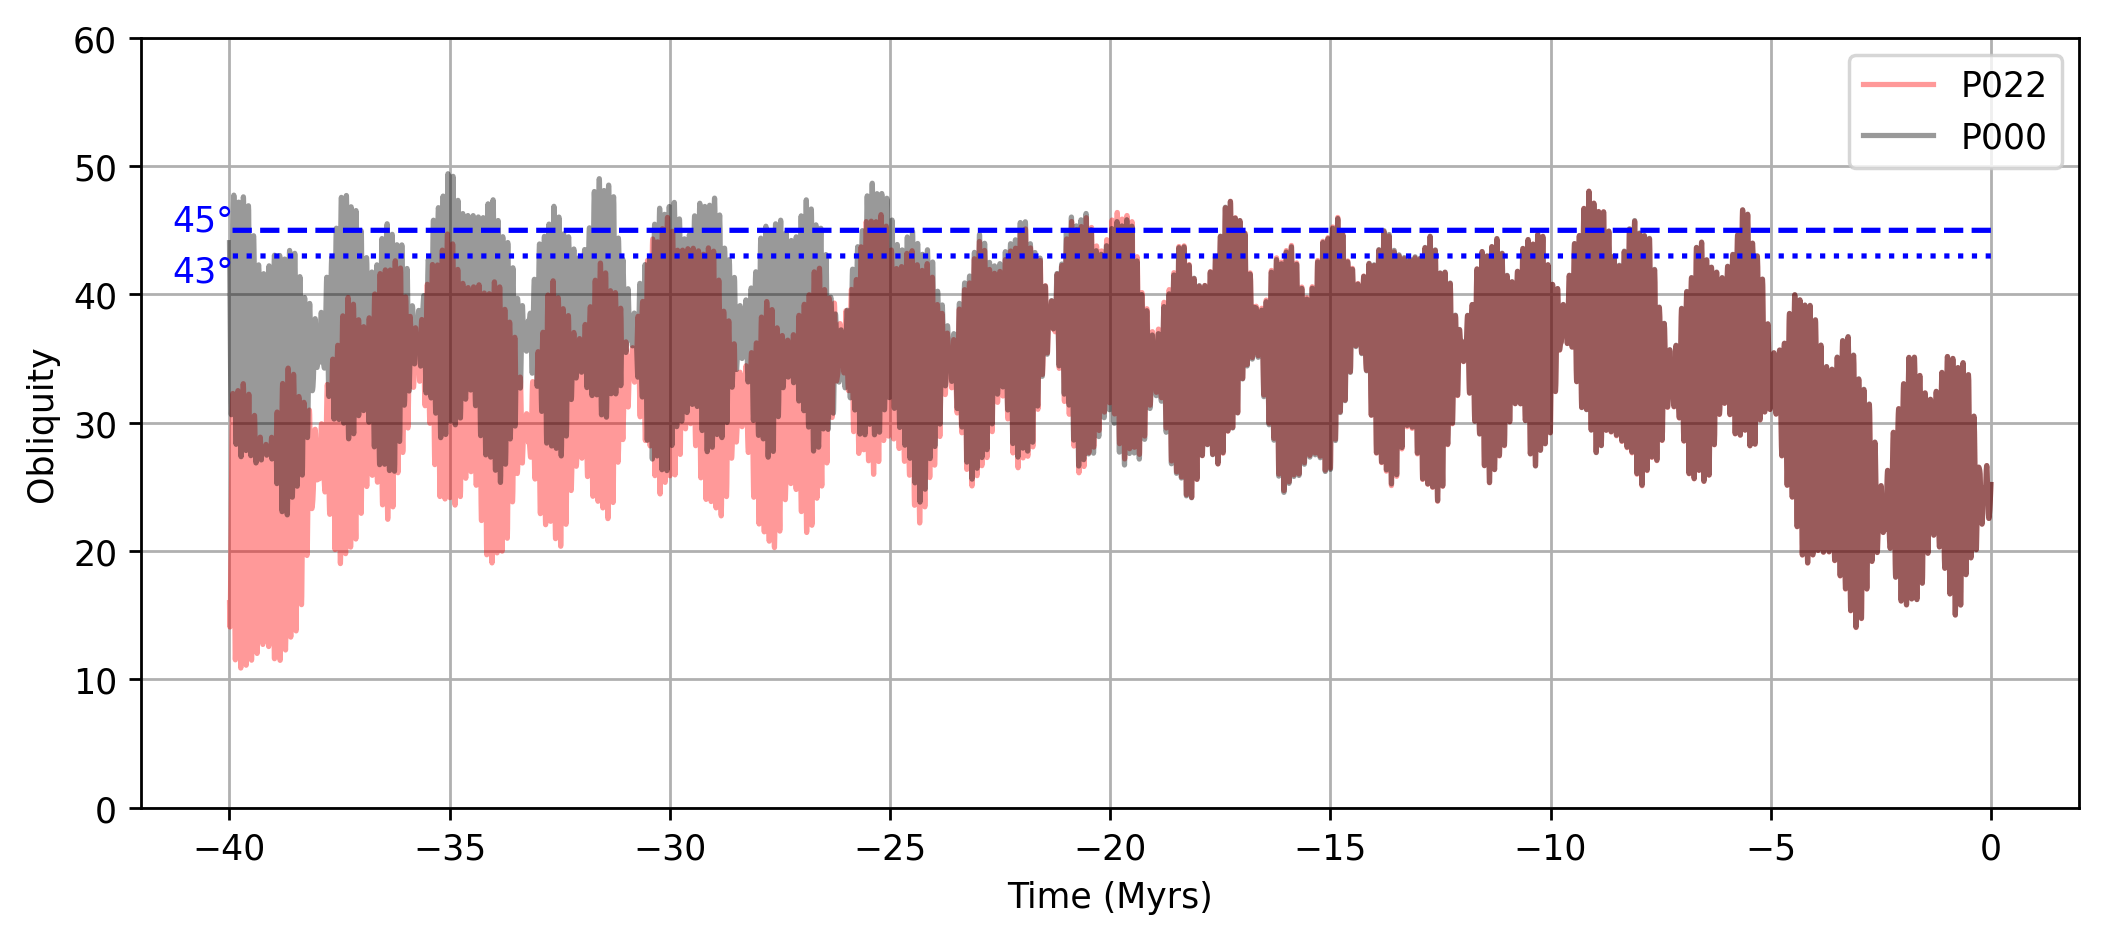

In [ ]:
plt.figure(figsize=(10, 4),dpi=250)
# plt.subplot(211)
plt.plot(df22.iloc[:40000, 0]/1000, df22.iloc[:40000, 2]*180./np.pi, 'red',label='P022',alpha=0.4)
plt.plot(df00.iloc[:40000, 0]/1000, df00.iloc[:40000, 2]*180./np.pi, 'black',label='P000',alpha=0.4)

# Plot horizontal lines
plt.plot(df00.iloc[:40000, 0]/1000, np.ones(40000)*45, color="blue",linestyle='--')
plt.plot(df00.iloc[:40000, 0]/1000, np.ones(40000)*43, color="blue",linestyle=':')

# Add annotations
plt.annotate('45\u00B0', xy=(-38, 45), xytext=(-41.3, 45), color='blue')
plt.annotate('43\u00B0', xy=(-38, 43), xytext=(-41.3, 41), color='blue')

plt.xlabel('Time (Myrs)')
plt.ylabel('Obliquity')
plt.ylim(0, 60)
# plt.title('Scatter plot of Column 1 vs Column 2')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

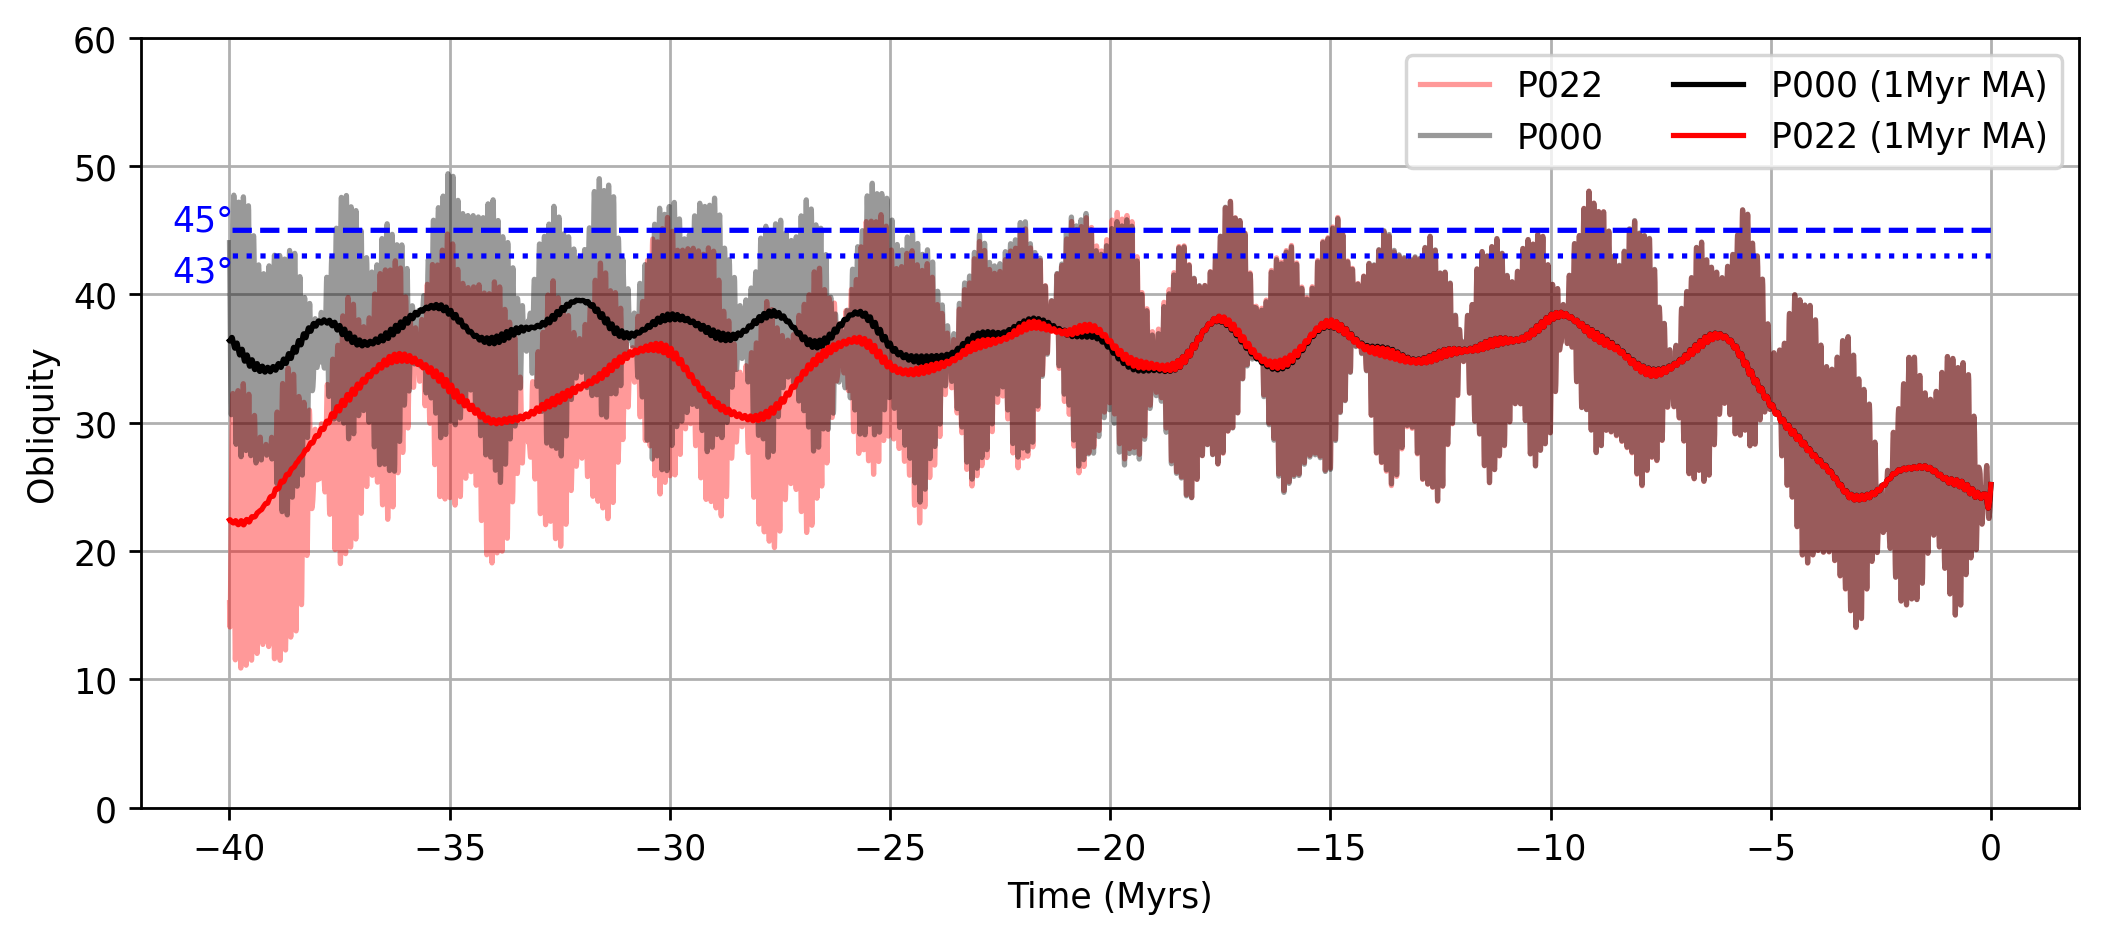

In [ ]:
plt.figure(figsize=(10, 4),dpi=250)

# Original data plots
plt.plot(df22.iloc[:40000, 0]/1000, df22.iloc[:40000, 2]*180./np.pi, 'red',label='P022',alpha=0.4)
plt.plot(df00.iloc[:40000, 0]/1000, df00.iloc[:40000, 2]*180./np.pi, 'black',label='P000',alpha=0.4)

# Calculate and plot 1 Myr moving average
rolling_window = 1000 # 1 Myr = 1000 kyrs

moving_avg_df00 = df00.iloc[:40000, 2].rolling(window=rolling_window, min_periods=1).mean()
moving_avg_df22 = df22.iloc[:40000, 2].rolling(window=rolling_window, min_periods=1).mean()

plt.plot(df00.iloc[:40000, 0]/1000, moving_avg_df00 * 180./np.pi, 'black', label='P000 (1Myr MA)')
plt.plot(df22.iloc[:40000, 0]/1000, moving_avg_df22 * 180./np.pi, 'red', label='P022 (1Myr MA)')

# Plot horizontal lines
plt.plot(df00.iloc[:40000, 0]/1000, np.ones(40000)*45, color="blue",linestyle='--')
plt.plot(df00.iloc[:40000, 0]/1000, np.ones(40000)*43, color="blue",linestyle=':')

# Add annotations
plt.annotate('45\u00B0', xy=(-38, 45), xytext=(-41.3, 45), color='blue')
plt.annotate('43\u00B0', xy=(-38, 43), xytext=(-41.3, 41), color='blue')

plt.xlabel('Time (Myrs)')
plt.ylabel('Obliquity')
plt.ylim(0, 60)
# plt.title('Obliquity with 1 Myr Moving Average')
plt.legend(loc='upper right', ncol=2)
plt.grid(True)
plt.show()

In [ ]:
# Load the CSV file into a pandas DataFrame.
try:
    # df = pd.read_csv('MontesSimulationCompile.csv')
    dfp01 = pd.read_csv('301003BIN_A_P001_N.ASC', delim_whitespace=True, header=None)
except FileNotFoundError:
    print("Error: '301003BIN_A_P001_N.ASC' not found. Please upload the file.")
    dfp01 = pd.DataFrame()  # Create an empty DataFrame to avoid further errors

/tmp/ipykernel_16147/3312919773.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfp01 = pd.read_csv('301003BIN_A_P001_N.ASC', delim_whitespace=True, header=None)


In [ ]:
# Load the CSV file into a pandas DataFrame.
try:
    # df = pd.read_csv('MontesSimulationCompile.csv')
    dfn01 = pd.read_csv('301003BIN_A_N001_N.ASC', delim_whitespace=True, header=None)
except FileNotFoundError:
    print("Error: '301003BIN_A_N001_N.ASC' not found. Please upload the file.")
    dfn01 = pd.DataFrame()  # Create an empty DataFrame to avoid further errors

/tmp/ipykernel_16147/3301926023.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfn01 = pd.read_csv('301003BIN_A_N001_N.ASC', delim_whitespace=True, header=None)


In [ ]:
# Load the CSV file into a pandas DataFrame.
try:
    # df = pd.read_csv('MontesSimulationCompile.csv')
    dfn06 = pd.read_csv('301003BIN_A_N006_N.ASC', delim_whitespace=True, header=None)
except FileNotFoundError:
    print("Error: '301003BIN_A_N006_N.ASC' not found. Please upload the file.")
    dfn06 = pd.DataFrame()  # Create an empty DataFrame to avoid further errors

/tmp/ipykernel_16147/4015872100.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfn06 = pd.read_csv('301003BIN_A_N006_N.ASC', delim_whitespace=True, header=None)


In [ ]:
dfn01.columns = ['Time (kyrs)', 'Eccentricity', 'Obliquity (r)', 'Precession']
dfn06.columns = ['Time (kyrs)', 'Eccentricity', 'Obliquity (r)', 'Precession']
dfp01.columns = ['Time (kyrs)', 'Eccentricity', 'Obliquity (r)', 'Precession']
df00.head()
df22.tail()

,Time (kyrs),Eccentricity,Obliquity (r),Precession
248996,-248996.0,0.043553,0.317489,5.142729
248997,-248997.0,0.042221,0.311935,5.015011
248998,-248998.0,0.040789,0.306212,4.889986
248999,-248999.0,0.039435,0.300352,4.765189
249000,-249000.0,0.038020,0.294336,4.637558


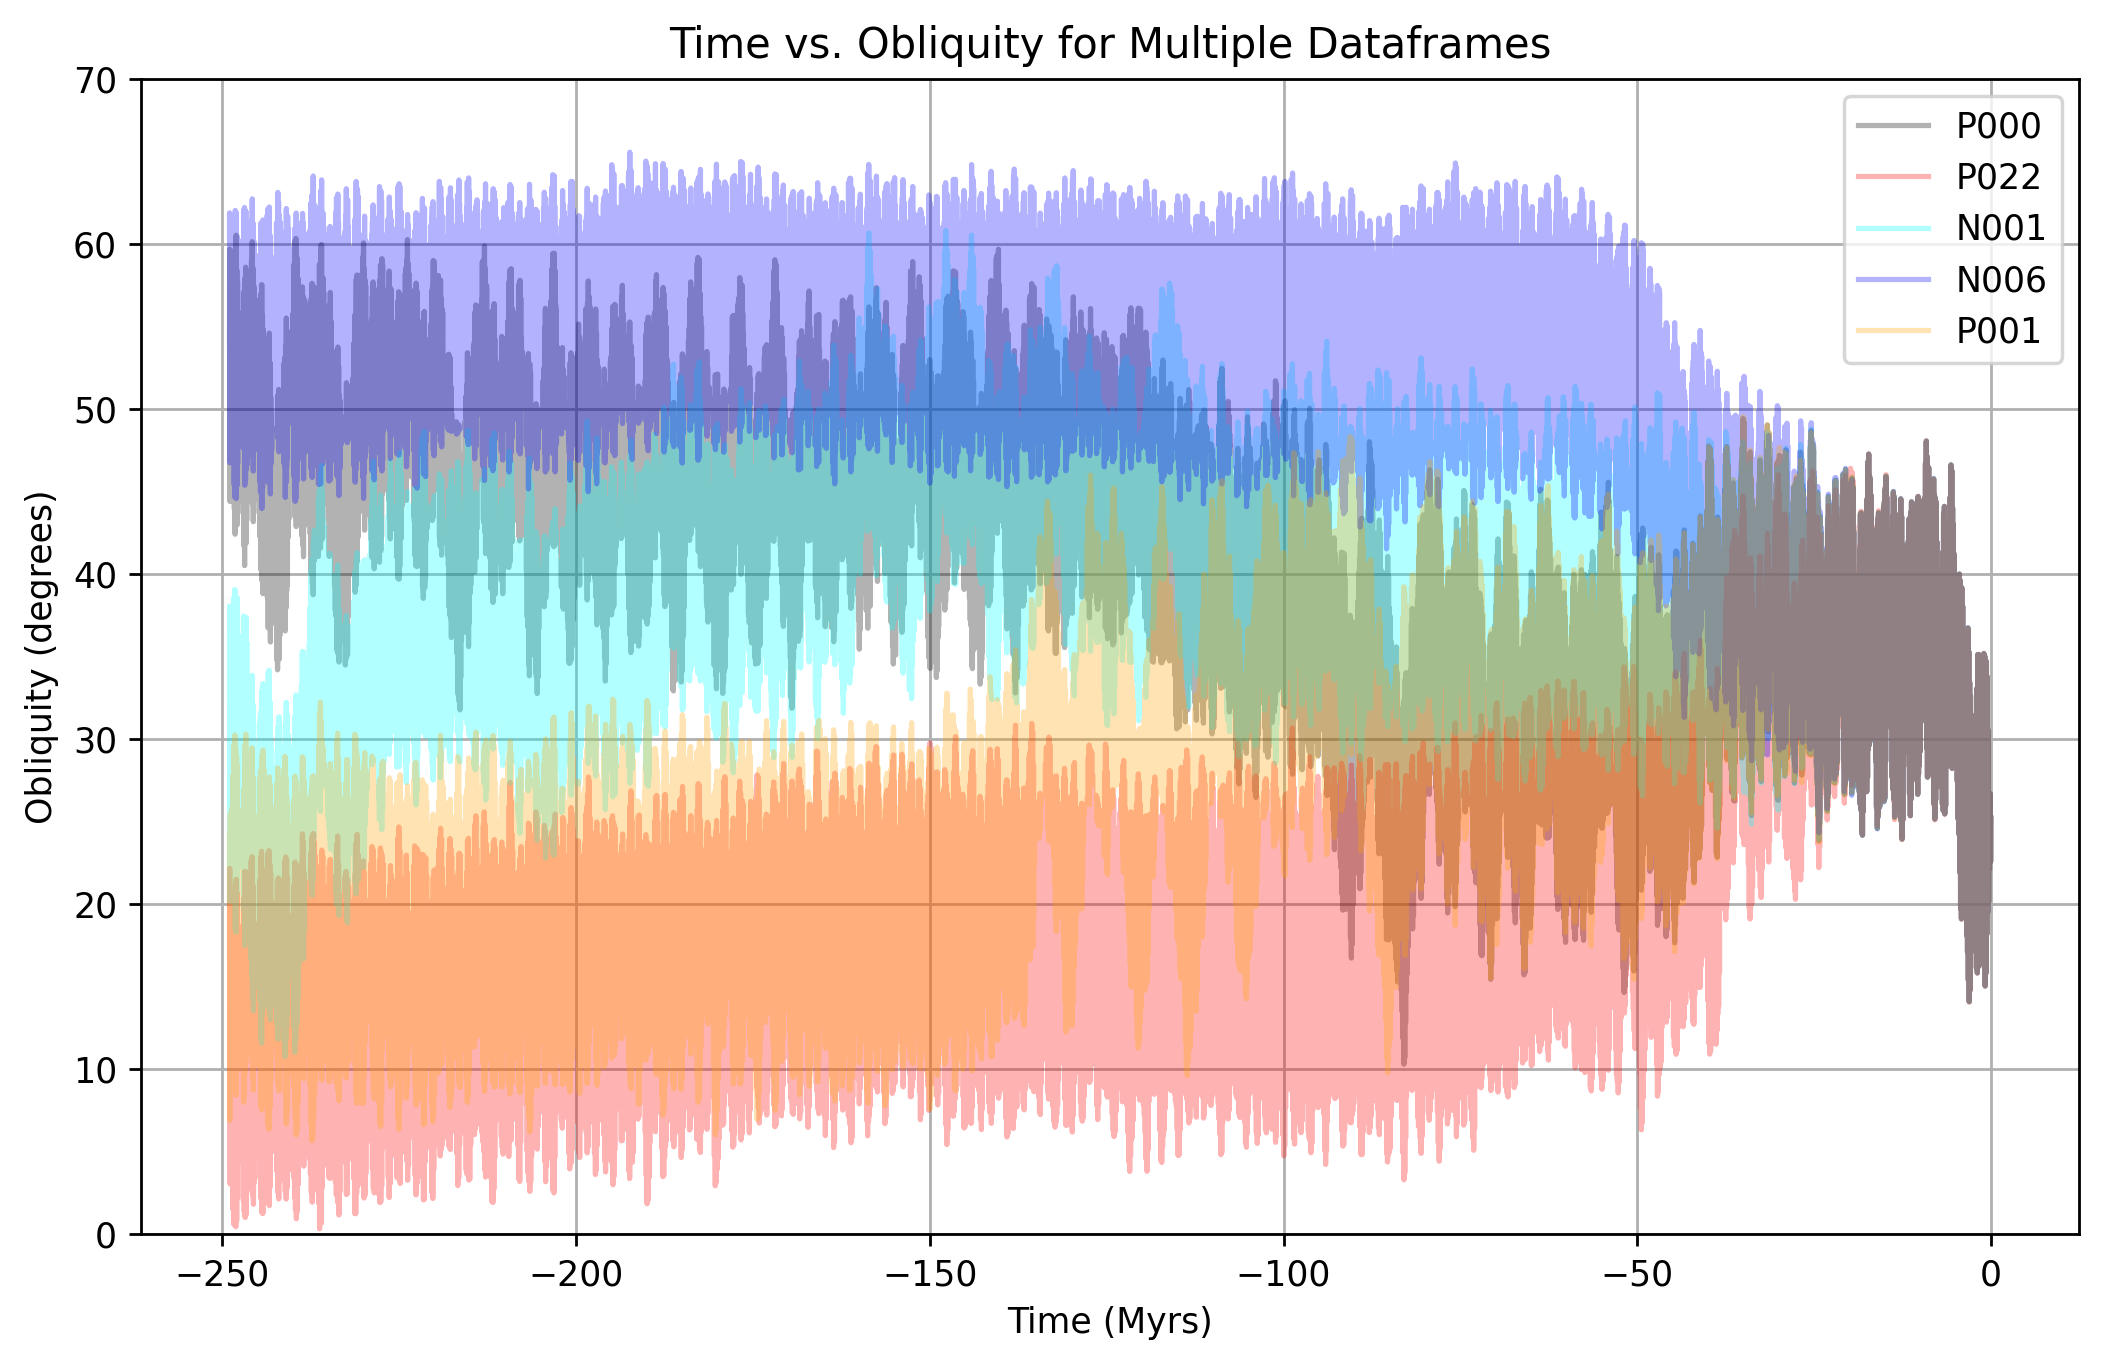

In [ ]:
plt.figure(figsize=(10, 6), dpi=250)

# Define dataframes and their labels
dataframes = {
    'P000': df00,
    'P022': df22,
    'N001': dfn01,
    'N006': dfn06,
    'P001': dfp01
}

colors = ['black', 'red', 'cyan', 'blue', 'orange']

for i, (label, df) in enumerate(dataframes.items()):
    plt.plot(df.iloc[:,0]/1000, df.iloc[:, 2]*180./np.pi, color=colors[i], label=label, alpha=0.3)

plt.xlabel('Time (Myrs)')
plt.ylabel('Obliquity (degrees)')
plt.ylim(0, 70)
plt.title('Time vs. Obliquity for Multiple Dataframes')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

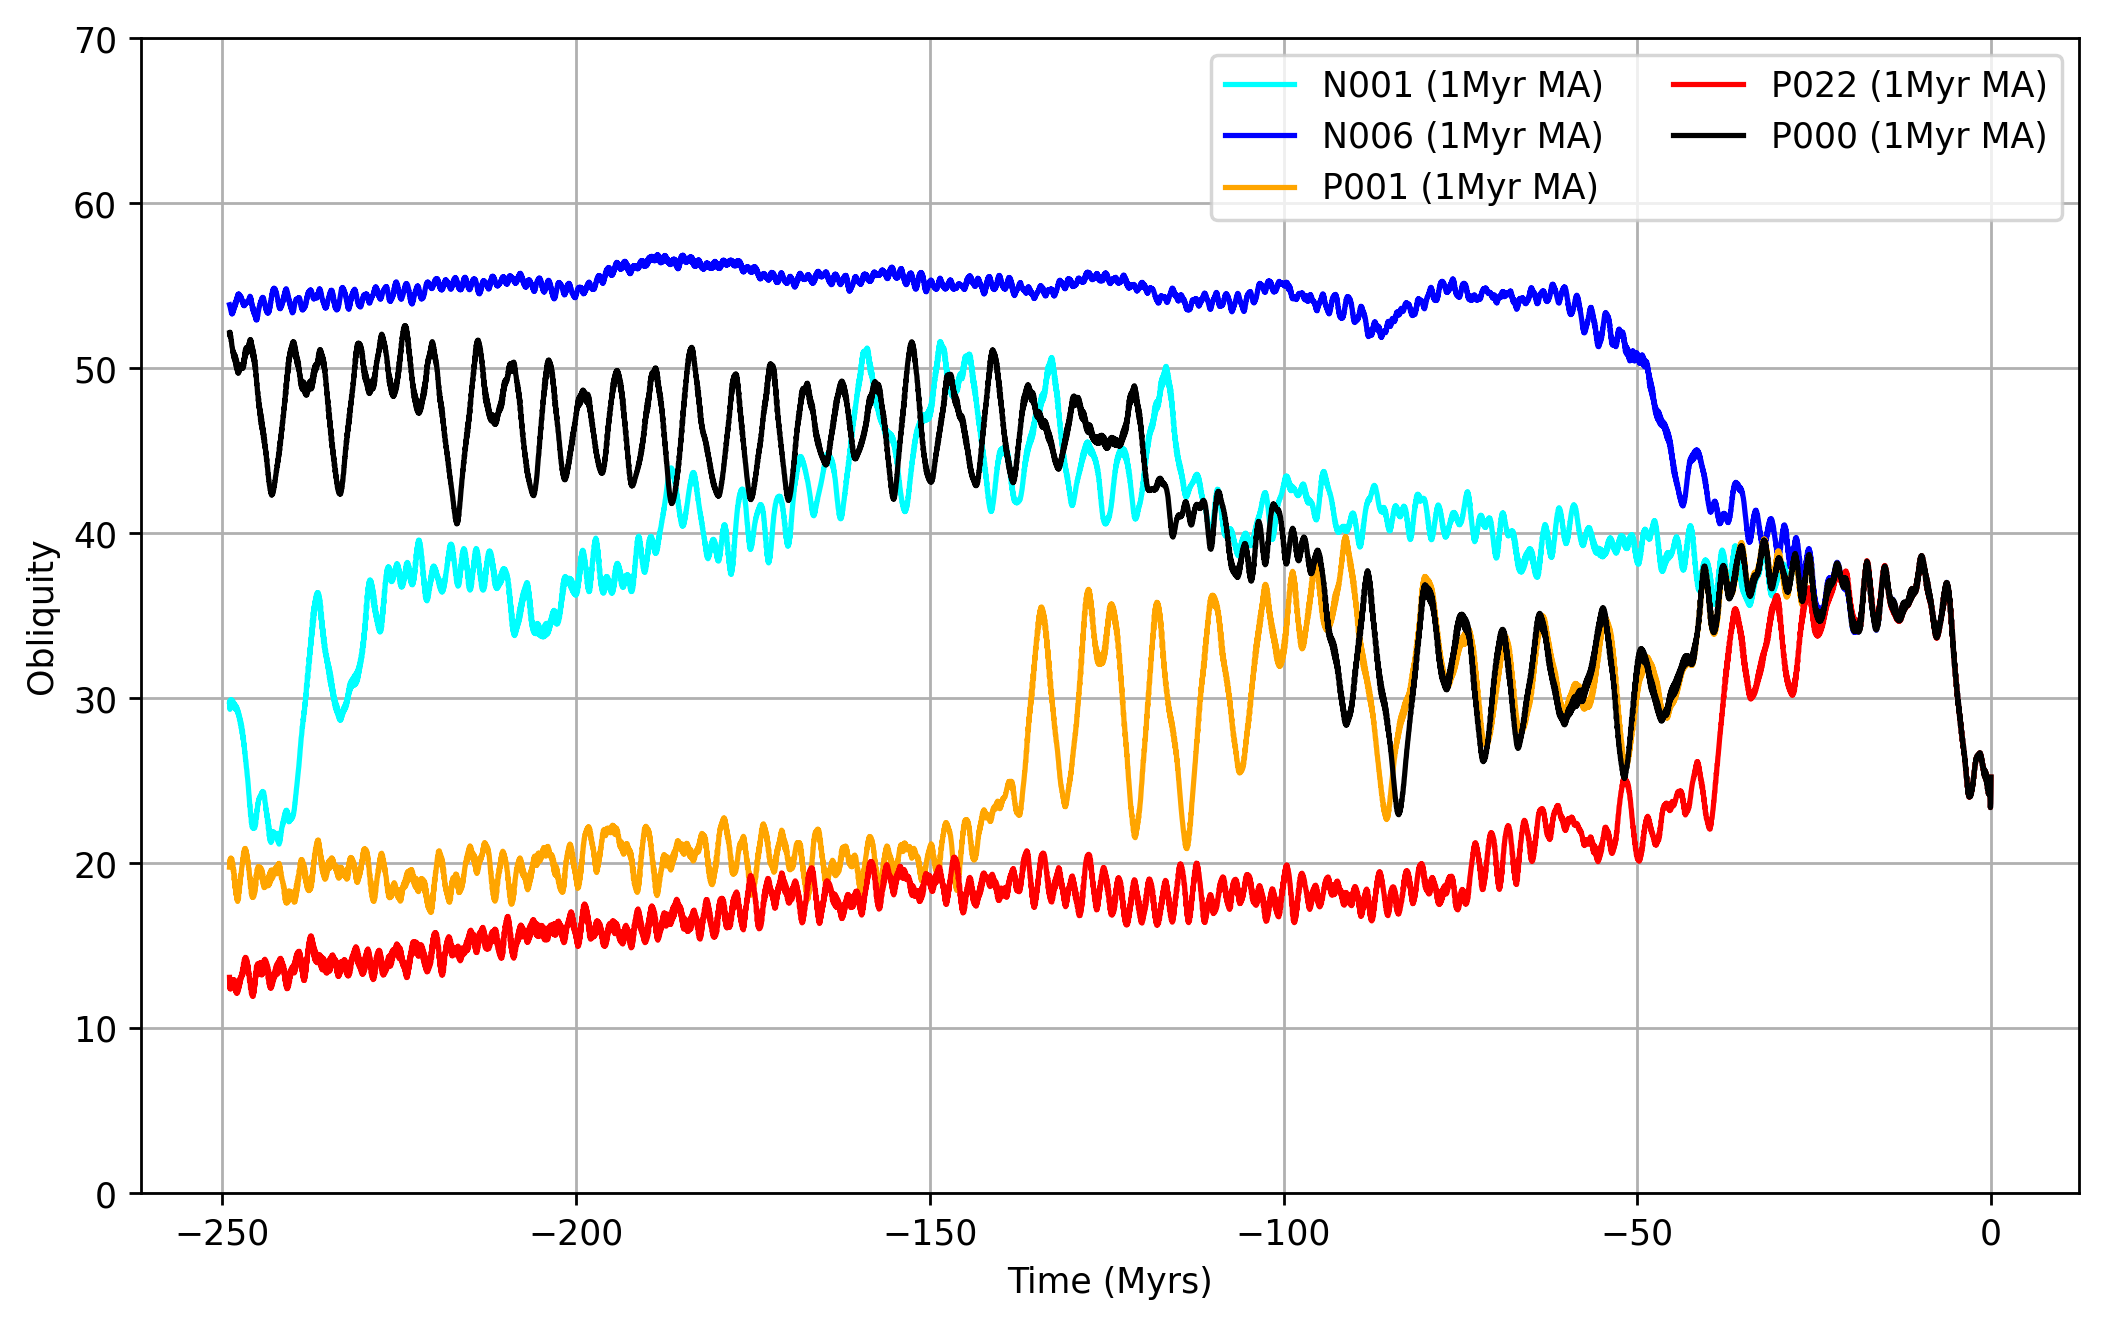

In [ ]:
plt.figure(figsize=(10, 6), dpi=250)

# Define dataframes and their labels
dataframes = {
    'N001': dfn01,
    'N006': dfn06,
    'P001': dfp01,
    'P022': df22,
    'P000': df00

}

colors = ['cyan', 'blue', 'orange', 'red','black']

for i, (label, df) in enumerate(dataframes.items()):
    # Plot original data
    # plt.plot(df.iloc[:,0]/1000, df.iloc[:, 2]*180./np.pi, color=colors[i], label=label, alpha=0.3)

    # Calculate and plot moving average (1 million years = 1000 kyrs)
    # Assuming data is sampled at 1 kyrs intervals, window size is 1000 points
    rolling_window = 1000
    moving_avg_obliquity = df.iloc[:, 2].rolling(window=rolling_window, min_periods=1).mean()
    plt.plot(df.iloc[:,0]/1000, moving_avg_obliquity * 180./np.pi, color=colors[i], label=label+' (1Myr MA)')

plt.xlabel('Time (Myrs)')
plt.ylabel('Obliquity')
plt.ylim(0, 70)
# plt.title('Time vs. Obliquity with 1 Myr Moving Average')
plt.legend(loc='upper right', ncol=2)
plt.grid(True)
plt.show()

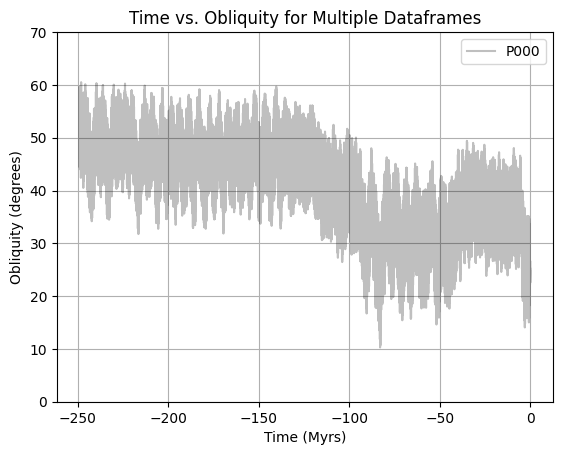

In [ ]:
plt.plot(df00.iloc[:, 0]/1000, df00.iloc[:, 2]*180./np.pi, 'black',label='P000',alpha=0.25)
plt.xlabel('Time (Myrs)')
plt.ylabel('Obliquity (degrees)')
plt.ylim(0, 70)
plt.title('Time vs. Obliquity for Multiple Dataframes')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()